## Middleware

In [1]:
from langchain.chat_models import init_chat_model

groq_model = init_chat_model(model = "groq:qwen/qwen3-32b")

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage ,SystemMessage

agent = create_agent(
    model=groq_model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=groq_model,
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

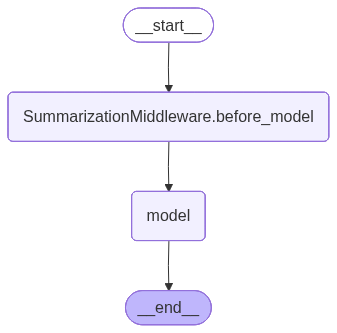

In [5]:
agent

In [6]:
config = {"configurable":{"thread_id":"test-1"}}

In [8]:
questions = [
    "what is 2 + 2 ?",
    "what is 10*5 ?",
    "what is 3*8 ? ",
    "what is 50/10 ?",
]


for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"messages:{response}")
    print(f"message length: {len(response["messages"])}")

messages:{'messages': [HumanMessage(content='what is 2 + 2 ?', additional_kwargs={}, response_metadata={}, id='2588db10-ad20-48eb-8b35-65ffe8aeec61'), AIMessage(content="<think>\nOkay, so I need to figure out what 2 plus 2 is. Let me start by recalling basic addition. When you add two numbers together, you're combining their quantities. So 2 plus 2 would be like having two apples and then getting two more apples. How many apples would that be in total?\n\nLet me count. If I have two apples and add another two, that's 1, 2, then 3, 4. So that's four apples. Wait, is that right? Maybe I should use my fingers to check. Hold on, I can't use my fingers since I'm a computer. Hmm.\n\nAlternatively, I can think of the number line. Starting at 2 and moving two places to the right would land me at 4. Yeah, that seems correct. Another way to check is by using the multiplication of 2 times 2, but wait, that's different. Multiplication is repeated addition, so 2 times 2 is 4, which is the same as 2

# Token size

In [ ]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool


@tool
def search_hotels(city:str) -> str:
   """search hotels and gives a long response """
   return f"""Hotels in {city}
   1. Grand Hotel 
   2. City Inn 
   3. Budget stay """


agent2 = create_agent(
    model=groq_model,
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=groq_model,
            trigger=("messages",550),
            keep=("messages",200)
        )
    ]
)




In [11]:
config = {"configurable":{"thread_id":"test-1"}}

In [ ]:
def count_messages_token(messages):
    tot_chars = sum(len(m.content) for m in messages)
    length = tot_chars // 4

    return length

In [ ]:
cities = [
    "Tokyo","London","Paris","Dubai"
]


for c in cities:
    response = agent.invoke({"messages":[HumanMessage(content=f"find me a hotel in {c}")]},config=config)
    tokens = count_messages_token(response["messages"])
    print(f"city{c},no of tokens : {tokens},length of messages:{len(response["messages"])}")
    print(f"message : {response["messages"]}")